# 03. Is the Truth True?

**The question.** Every NC-data experiment in this lab plans to score itself against `ncid` — the
statewide identifier the NC State Board of Elections assigns to each registrant. Calling that
column `entity_id` is a decision, not a fact: NCID is an *administrative* key, maintained for
registration bookkeeping by 100 county boards, and nobody audits its error rate before papers
inherit it as gold. If NCID is wrong in ways we have not measured, every "accuracy" number the lab
later reports on NC data is an accuracy *relative to an unaudited teacher*. So before any model
exists, this notebook asks: **how wrong is the truth key, in which directions, and is it usable as
pseudo-truth at all?** (MET-05 — the feasibility gate for every NC-truth arm) — and, separately:
**which records could no method ever resolve, truth key or not?** (MET-06 — the identifiability
accounting every later headline metric must carry).

**What this notebook settles.** Four things: (1) the gate criteria for NCID-as-pseudo-truth,
pre-registered as a conjecture card *before* the measurement, then measured at county-subset scale
with Wilson 95% intervals — within-snapshot duplicate-NCID share (decomposed into registration
history vs residual), the exclusion pressure those duplicates put on the aligned audit substrate,
and cross-snapshot *overlay suspects* (one NCID, seemingly two different people); (2) the
`met05_ncid_audit` artifact and a preliminary gate decision — loudly scoped: the DEFINITIVE gate
is the statewide target-tier rerun; (3) the MET-06 unresolvable-fraction report over four declared
field sets on the real NC corpus (which has **no full DOB** — only `age`), with per-sex/per-race
breakdowns, registered as `met06_identifiability`; (4) the human adjudication protocol — the
deterministic pair queue over real disagreement strata, the target-tier sample size from a power
computation, and the inter-rater agreement plan — because where the file cannot tell overlay from
name change, only teacher-independent labels can.

In [1]:
import math
import time

import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

from er_lab.config import REPO_ROOT, config_hash, load_config_from_env, set_all_seeds
from er_lab.eval.identifiability import unresolvable_mask, unresolvable_report
from er_lab.infra.artifacts import ArtifactRegistry
from er_lab.infra.device import describe_platform
from er_lab.label.widget import PairQueue
from er_lab.noise.audit import classify_pair_diffs, prevalence
from er_lab.reporting import figures
from er_lab.reporting.cards import conjecture_card, verdict_box

cfg = load_config_from_env()
registry = ArtifactRegistry.from_env()
figures.setup_style()
set_all_seeds(cfg.run.seed)
NB_T0 = time.time()

In [2]:
# Tier banner — where and under what config this run happened.
print(f"tier        = {cfg.run.tier}")
print(f"config hash = {config_hash(cfg)}")
for key, val in describe_platform().items():
    print(f"  {key:>14}: {val}")

tier        = smoke
config hash = 129c9d9243ca
              os: Linux-6.18.44-fc-v21-x86_64-with-glibc2.39
          python: 3.11.15
           torch: 2.13.0+cu130
  cuda_available: False
   mps_available: False
       cpu_count: 4
          ram_gb: 15.7


## Tier constants

The substrate itself is not sized here: it arrives through the `corpus_registry` artifact, which
notebook 01 built at this same tier (county subset at smoke/mid, statewide at target) — one code
path, the tier only changes what notebook 01 registered. What *is* tier-keyed below: the scope
label stamped into the gate decision (a county subset can only ever yield a *preliminary* pass),
and the size of the demonstration adjudication queue.

In [3]:
GATE_SCOPE = {
    "smoke": "county_subset_preliminary",
    "mid": "county_subset_preliminary",
    "target": "statewide_definitive",
    "analytical": "county_subset_preliminary",
}[cfg.run.tier]
QUEUE_N = {"smoke": 10, "mid": 10, "target": 500, "analytical": 10}[cfg.run.tier]

DATA_ROOT = REPO_ROOT  # corpus_registry paths are repo-root-relative
print(f"tier={cfg.run.tier}: gate scope = '{GATE_SCOPE}', demo queue size = {QUEUE_N}")

tier=smoke: gate scope = 'county_subset_preliminary', demo queue size = 10


## 1. The circularity problem

NCID is assigned when a person registers and is *supposed* to follow them through moves,
re-registrations, name changes, and list maintenance. But it is an administrative key: its
custodians optimize registration bookkeeping, not identity adjudication, and its own error rate
is unaudited — the literature that uses NC voter data as an ER benchmark (the fastLink line, the
Christen-group NCVR benchmarks) simply *assumes* NCID is reliable ground truth, an assumption
dozens of papers inherit and none test (lit_review §8). Administrative person keys in general
carry duplicates (one person, several keys) and overlays (one key, several people) at materially
nonzero, site-varying rates; only the existence is settled — no specific rate transfers from one
registry to another, which is exactly why it must be *measured here, on this key*.

The errors poison evaluation asymmetrically, and the asymmetry matters more than the rate. An
**overlay** manufactures a false "true match": a system that correctly refuses to merge two
different people sharing an NCID is scored as missing a match, so measured recall and precision
both degrade *for the better system*. A **duplicate** (one person under two NCIDs) manufactures a
false "true non-match": a system that correctly merges them is punished as a false positive —
which biases every comparison toward whatever conservative process produced the key in the first
place (imperfect-gold-standard bias: agreement metrics against teacher-correlated labels are
biased toward the teacher — lit_review §4/§8). Worse, admin-key error is not class-conditional
noise: linkage and registry errors concentrate in high-mobility and minority subgroups, so the
inherited label noise is instance- and subgroup-dependent — precisely the structure that breaks
the standard noisy-label toolbox and precisely what FAIR-01 must not inherit silently. The only
honest sequence is: audit the key, gate its use, and adjudicate its disagreements with
teacher-independent human labels. That is this notebook.

In [4]:
# The inherited evidence: notebook 01's corpus_registry (hard-fails if 01 has not run at this tier).
corpus, corpus_meta = registry.load("corpus_registry", tier=cfg.run.tier)
nc_info = corpus["nc_snapshots"]
SNAP_A, SNAP_B = nc_info["a"]["date"], nc_info["b"]["date"]
snap_paths = {
    SNAP_A: DATA_ROOT / nc_info["a"]["path"],
    SNAP_B: DATA_ROOT / nc_info["b"]["path"],
}
aligned_path = DATA_ROOT / nc_info["aligned_path"]
align_stats = nc_info["align_stats"]
print(f"snapshots     : {SNAP_A} ({nc_info['a']['n_records']} records) / "
      f"{SNAP_B} ({nc_info['b']['n_records']} records)")
print(f"counties      : {nc_info['counties']} (None = statewide)")
print(f"aligned pairs : {align_stats['pairs']}  (recorded by notebook 01)")
print(f"dup ncids excluded from the join: a={align_stats['dup_ncids_a']}, "
      f"b={align_stats['dup_ncids_b']}  <- MET-05's first inherited evidence")

snapshots     : 20240101 (423135 records) / 20260101 (447450 records)
counties      : [68] (None = statewide)
aligned pairs : 391257  (recorded by notebook 01)
dup ncids excluded from the join: a=13226, b=15775  <- MET-05's first inherited evidence


## 2. The gate, stated before the measurement

The card below pre-registers what "NCID is usable as pseudo-truth" *means*, numerically, before
any of it is computed in this run. Two clauses deserve a word on where their thresholds come
from. The duplicate-share ceiling (G1) is about *substrate survival*, not truth error: NC
snapshots retain the county's registration **history** (removed and inactive rows sit beside
active ones), so one NCID legitimately carries several rows of the same person — those rows are
correctly labeled same-entity; the cost is that `align_pair` excludes every duplicated NCID from
the audit substrate, and notebook 01 already recorded that exclusion at the low-percent level.
What would be alarming is duplication *not* explained by history (G2) — same NCID, same
registration event, different rows — or duplication so heavy the audit substrate stops being
representative. The overlay threshold (G3) is about truth error where it hurts most: the lab's
operating points fix entity precision at 0.99/0.995, i.e. a false-positive budget of 0.5–1%, so
truth-side false "matches" must sit well below that budget to be ignorable — we require an order
of magnitude of headroom.

In [5]:
G1_DUP_SHARE_MAX = 0.05  # duplicated-ncid share of distinct ncids, per snapshot
G2_RESIDUAL_MAX = 0.01  # duplicated ncids NOT explained by registration history, per snapshot
G3_OVERLAY_MAX = 0.002  # overlay suspects per aligned pair (10x below the 0.995-precision budget)
_ = conjecture_card(
    card_id="MET-05-NCID-GATE",
    conjecture=(
        "NCID is usable as pseudo-truth for NC arms once duplicated ncids are excluded: "
        "within-snapshot duplication is dominated by retained registration history (not key "
        "errors), and genuine overlays (one ncid carrying two different people) are rare enough "
        "that entity-level metrics scored against NCID are not dominated by truth error."
    ),
    pressure=(
        "administrative key practice: NCID assignment and maintenance across county boards, "
        "probed via two snapshots two years apart at this tier's scope"
    ),
    property=(
        "measured key-error surrogates: within-snapshot duplicated-ncid share and its "
        "registration-history decomposition; aligned-substrate exclusion pressure; cross-snapshot "
        "overlay-suspect rate (both names wholesale-different AND age gap inconsistent with "
        "elapsed time)"
    ),
    metric=(
        "gate clauses with Wilson 95% CIs: G1 duplicated-ncid share per snapshot; G2 residual "
        "(non-history) duplicated-ncid share per snapshot; G3 overlay-suspect rate per aligned "
        "pair"
    ),
    prediction=(
        "G1 < 5% of distinct ncids per snapshot (notebook 01's align_stats already recorded "
        "~3% side-level exclusions, so this clause should pass and cross-check); G2 < 1% of "
        "distinct ncids; G3 < 0.2% of aligned pairs. All three -> preliminary pass at county "
        "subset; the DEFINITIVE gate is the statewide target-tier rerun of these same cells."
    ),
    registry=registry,
)

### Conjecture card `MET-05-NCID-GATE`

| | |
|---|---|
| **Conjecture** | NCID is usable as pseudo-truth for NC arms once duplicated ncids are excluded: within-snapshot duplication is dominated by retained registration history (not key errors), and genuine overlays (one ncid carrying two different people) are rare enough that entity-level metrics scored against NCID are not dominated by truth error. |
| **Pressure (dial)** | administrative key practice: NCID assignment and maintenance across county boards, probed via two snapshots two years apart at this tier's scope |
| **Embedding property** | measured key-error surrogates: within-snapshot duplicated-ncid share and its registration-history decomposition; aligned-substrate exclusion pressure; cross-snapshot overlay-suspect rate (both names wholesale-different AND age gap inconsistent with elapsed time) |
| **System metric** | gate clauses with Wilson 95% CIs: G1 duplicated-ncid share per snapshot; G2 residual (non-history) duplicated-ncid share per snapshot; G3 overlay-suspect rate per aligned pair |
| **Pre-registered prediction** | G1 < 5% of distinct ncids per snapshot (notebook 01's align_stats already recorded ~3% side-level exclusions, so this clause should pass and cross-check); G2 < 1% of distinct ncids; G3 < 0.2% of aligned pairs. All three -> preliminary pass at county subset; the DEFINITIVE gate is the statewide target-tier rerun of these same cells. |

*Immutable — sha256 `e49fd780c089`; registered before the affected runs, never edited (PLAN §5).*


### The measurement machinery: one interval, stated once

Every rate in this notebook is `k` events in `n` trials with a **Wilson 95% score interval** —
the same interval `noise.audit.prevalence` stamps on its tables, restated here as a scalar
helper so the audit's one-off counts (gate clauses, conjunctions, zero counts) carry the
identical uncertainty convention. Wilson rather than Wald because several of our counts are tiny
or zero, exactly where the Wald interval collapses to a lying `[p, p]`.

In [6]:
Z95 = float(norm.ppf(0.975))


def wilson_ci(k: int, n: int) -> tuple[float, float]:
    """Wilson 95% score interval for k successes in n trials (same form as noise.audit)."""
    p, z2 = k / n, Z95 * Z95
    denom = 1.0 + z2 / n
    center = (p + z2 / (2.0 * n)) / denom
    half = Z95 * math.sqrt(p * (1.0 - p) / n + z2 / (4.0 * n * n)) / denom
    return max(center - half, 0.0), min(center + half, 1.0)


def measure(name: str, snapshot: str, k: int, n: int, denominator: str,
            gate: str = "", threshold: float = float("nan")) -> dict:
    """One audit row: rate + Wilson CI, plus (optionally) the gate clause it feeds."""
    lo, hi = wilson_ci(k, n)
    return {
        "measure": name, "snapshot": snapshot, "k": int(k), "n": int(n),
        "denominator": denominator, "rate": k / n, "ci_low": lo, "ci_high": hi,
        "gate": gate, "threshold": threshold,
        "passed": bool(k / n < threshold) if gate else pd.NA,
    }


print(f"z(0.975) = {Z95:.4f}; example: 0 events in {align_stats['pairs']} pairs -> "
      f"upper bound {wilson_ci(0, align_stats['pairs'])[1]:.2e}")

z(0.975) = 1.9600; example: 0 events in 391257 pairs -> upper bound 9.82e-06


### 2a. Within-snapshot duplicate NCIDs — and what kind of duplicates they are

`groupby(ncid)` on each snapshot. A duplicated NCID here is *not* automatically a key error:
because the snapshot retains history, a person removed and later re-registered can sit in the
file twice under one NCID — different registration events, both genuinely them. So each
duplicated NCID group is decomposed by its distinct `registr_dt` values: **multiple registration
dates** = the history explanation fits; **a single registration date** = two rows from the *same*
registration event, which history cannot explain — the residual where within-snapshot overlays
and processing errors would live (G2). We also count how many groups disagree on the name pair —
name churn inside one NCID is what makes the overlay question non-trivial.

In [7]:
def dup_profile(date: str) -> dict:
    """Duplicate-ncid share and its registration-history decomposition for one snapshot."""
    snap = pd.read_parquet(
        snap_paths[date], columns=["ncid", "registr_dt", "status_cd", "given_name", "family_name"]
    )
    counts = snap["ncid"].value_counts()
    dup_ids = counts.index[counts > 1]
    dup_rows = snap[snap["ncid"].isin(dup_ids)].copy()
    dup_rows["name_pair"] = (
        dup_rows["given_name"].str.strip() + "|" + dup_rows["family_name"].str.strip()
    )
    groups = dup_rows.groupby("ncid").agg(
        rows=("ncid", "size"),
        n_regdt=("registr_dt", "nunique"),
        n_names=("name_pair", "nunique"),
    )
    return {
        "rows": len(snap),
        "n_ncids": len(counts),
        "dup_ncids": len(dup_ids),
        "multi_regdt": int((groups["n_regdt"] > 1).sum()),
        "single_regdt": int((groups["n_regdt"] == 1).sum()),
        "name_churn_groups": int((groups["n_names"] > 1).sum()),
        "max_rows_per_ncid": int(groups["rows"].max()) if len(groups) else 1,
    }


profiles = {d: dup_profile(d) for d in (SNAP_A, SNAP_B)}
display(pd.DataFrame(profiles).T)

,rows,n_ncids,dup_ncids,multi_regdt,single_regdt,name_churn_groups,max_rows_per_ncid
20240101,423135,407815,13226,12921,305,1654,6
20260101,447450,429139,15775,15428,347,2071,7


In [8]:
audit_rows = []
for d, p in profiles.items():
    audit_rows.append(measure("dup_ncid_share", d, p["dup_ncids"], p["n_ncids"],
                              "distinct ncids", gate="G1", threshold=G1_DUP_SHARE_MAX))
    audit_rows.append(measure("dup_residual_single_regdt", d, p["single_regdt"], p["n_ncids"],
                              "distinct ncids", gate="G2", threshold=G2_RESIDUAL_MAX))
    audit_rows.append(measure("dup_history_multi_regdt", d, p["multi_regdt"],
                              max(p["dup_ncids"], 1), "duplicated ncids"))
    audit_rows.append(measure("dup_name_churn", d, p["name_churn_groups"],
                              max(p["dup_ncids"], 1), "duplicated ncids"))
for row in audit_rows:
    print(f"{row['measure']:>26} {row['snapshot']}: {row['k']:>6} / {row['n']} "
          f"= {row['rate']:.4%}  CI [{row['ci_low']:.4%}, {row['ci_high']:.4%}]"
          + (f"  gate {row['gate']} (<{row['threshold']:.1%}): "
             f"{'PASS' if row['passed'] else 'FAIL'}" if row["gate"] else ""))

            dup_ncid_share 20240101:  13226 / 407815 = 3.2431%  CI [3.1892%, 3.2979%]  gate G1 (<5.0%): PASS
 dup_residual_single_regdt 20240101:    305 / 407815 = 0.0748%  CI [0.0669%, 0.0837%]  gate G2 (<1.0%): PASS
   dup_history_multi_regdt 20240101:  12921 / 13226 = 97.6939%  CI [97.4239%, 97.9362%]
            dup_name_churn 20240101:   1654 / 13226 = 12.5057%  CI [11.9528%, 13.0803%]
            dup_ncid_share 20260101:  15775 / 429139 = 3.6760%  CI [3.6201%, 3.7327%]  gate G1 (<5.0%): PASS
 dup_residual_single_regdt 20260101:    347 / 429139 = 0.0809%  CI [0.0728%, 0.0898%]  gate G2 (<1.0%): PASS
   dup_history_multi_regdt 20260101:  15428 / 15775 = 97.8003%  CI [97.5595%, 98.0178%]
            dup_name_churn 20260101:   2071 / 15775 = 13.1284%  CI [12.6103%, 13.6644%]


### 2b. The exclusion pressure on the audit substrate — cross-checked against notebook 01

`align_pair` (notebook 01) excluded every duplicated NCID from the aligned same-person pairs and
recorded how many per side. Those recorded counts must equal the fresh `groupby` above — if they
do not, the shipped substrate and its provenance record have drifted apart and nothing downstream
is trustworthy, so the check is a hard assert, not a warning.

The exclusion itself is a **selection effect the lab must carry**: the decomposition above shows
most duplicated NCIDs are re-registration histories, so the excluded people are disproportionately
the *mobile* ones — and registry error concentrates in exactly that population. The aligned diff
substrate that notebook 04 audits is therefore biased toward stable registrants; NSE-01's
prevalence numbers are lower bounds for the mobile subpopulation. Recorded here, revisited in
notebook 04's exposure model.

In [9]:
recorded = {SNAP_A: align_stats["dup_ncids_a"], SNAP_B: align_stats["dup_ncids_b"]}
for d in (SNAP_A, SNAP_B):
    fresh = profiles[d]["dup_ncids"]
    assert fresh == recorded[d], (
        f"substrate drift: fresh dup-ncid count {fresh} != recorded align_stats {recorded[d]} "
        f"for snapshot {d} — re-run notebook 01 before trusting anything downstream"
    )
    side = "a" if d == SNAP_A else "b"
    audit_rows.append(measure("align_excluded_ncids", d, recorded[d], profiles[d]["n_ncids"],
                              "distinct ncids"))
    print(f"snapshot {d} (side {side}): recorded exclusions {recorded[d]} == fresh groupby "
          f"{fresh}  OK")
print("\nalign_stats reproduce from the shipped parquets — the substrate and its provenance agree.")

snapshot 20240101 (side a): recorded exclusions 13226 == fresh groupby 13226  OK
snapshot 20260101 (side b): recorded exclusions 15775 == fresh groupby 15775  OK

align_stats reproduce from the shipped parquets — the substrate and its provenance agree.


### 2c. Overlay suspects: one NCID, two people?

The sharpest overlay evidence available without human labels: a same-NCID aligned pair whose
**family name AND given name are both `wholesale`-different** (the `noise.audit` taxonomy's
residual category — not a typo, not format drift, not a within-record swap, not missing) **and**
whose **age gap is inconsistent with the elapsed time** between the snapshots. Each margin alone
is innocent — both names change legally (marriage plus a given-name change), and an age can jump
because a clerical error was *fixed* — but a pair failing both margins at once looks like two
different people time-sharing one key. Two honesty notes: we classify without a nickname lexicon
(notebook 04 introduces it), so nickname swaps land in `wholesale` for given names — conservative
for the conjunction, since the family name must *also* be wholesale-different; and ages are
compared as integers with a ±1-year tolerance band around the elapsed time.

In [10]:
audit_fields = ["given_name", "family_name"]
pair_cols = ["ncid"] + [
    f"{f}_{s}"
    for f in ("given_name", "middle_name", "family_name", "age", "sex", "race",
              "street", "city", "status_cd", "registr_dt")
    for s in ("a", "b")
]
aligned = pd.read_parquet(aligned_path, columns=pair_cols)
t0 = time.time()
long_df = classify_pair_diffs(aligned, fields=audit_fields)
print(f"classified {len(aligned)} aligned pairs x {audit_fields} "
      f"in {time.time() - t0:.1f}s")
print("\nname diff-mix with Wilson CIs (the NSE-01 preview — notebook 04 owns the full audit):")
display(prevalence(long_df))

classified 391257 aligned pairs x ['given_name', 'family_name'] in 3.4s

name diff-mix with Wilson CIs (the NSE-01 preview — notebook 04 owns the full audit):


,field,category,n,rate,ci_low,ci_high
0,family_name,format_drift,624,0.001595,1.474623e-03,0.001725
1,family_name,identical,390049,0.996913,9.967337e-01,0.997082
2,family_name,swap,12,0.000031,1.754548e-05,0.000054
3,family_name,typo,72,0.000184,1.461451e-04,0.000232
4,family_name,wholesale,500,0.001278,1.170780e-03,0.001395
5,given_name,format_drift,155,0.000396,3.385177e-04,0.000464
6,given_name,identical,390832,0.998914,9.988055e-01,0.999012
7,given_name,missing_loss,1,0.000003,4.511730e-07,0.000014
8,given_name,swap,13,0.000033,1.941855e-05,0.000057
9,given_name,typo,106,0.000271,2.240275e-04,0.000328


In [11]:
# The age-consistency band, derived from the snapshot dates themselves (one code path, any pair).
elapsed_years = (pd.Timestamp(SNAP_B) - pd.Timestamp(SNAP_A)).days / 365.25
AGE_BAND = (math.floor(elapsed_years) - 1, math.ceil(elapsed_years) + 1)
age_a = pd.to_numeric(aligned["age_a"].str.strip(), errors="coerce")
age_b = pd.to_numeric(aligned["age_b"].str.strip(), errors="coerce")
dage = age_b - age_a
n_unparseable = int((age_a.isna() | age_b.isna()).sum())
age_incons = dage.notna() & ~dage.between(*AGE_BAND)
print(f"elapsed time {elapsed_years:.2f} years -> consistent age gap band {AGE_BAND}")
print(f"unparseable ages: {n_unparseable} pairs (excluded from the inconsistency margin)")

elapsed time 2.00 years -> consistent age gap band (1, 4)
unparseable ages: 0 pairs (excluded from the inconsistency margin)


In [12]:
wide = long_df.pivot(index="key", columns="field", values="category")
both_wholesale = (wide["given_name"] == "wholesale") & (wide["family_name"] == "wholesale")
flags = pd.DataFrame({
    "ncid": aligned["ncid"],
    "names_wholesale": aligned["ncid"].map(both_wholesale).fillna(False).astype(bool),
    "age_incons": age_incons.to_numpy(),
    "dage": dage.to_numpy(),
})
flags["overlay_suspect"] = flags["names_wholesale"] & flags["age_incons"]
n_pairs = len(flags)
for name, k in (("names_wholesale_both", flags["names_wholesale"].sum()),
                ("age_gap_inconsistent", flags["age_incons"].sum())):
    audit_rows.append(measure(name, "pair", int(k), n_pairs, "aligned pairs"))
audit_rows.append(measure("overlay_suspect", "pair", int(flags["overlay_suspect"].sum()),
                          n_pairs, "aligned pairs", gate="G3", threshold=G3_OVERLAY_MAX))
for row in audit_rows[-3:]:
    print(f"{row['measure']:>22}: {row['k']:>4} / {row['n']} = {row['rate']:.5%}  "
          f"CI [{row['ci_low']:.5%}, {row['ci_high']:.5%}]"
          + (f"  gate {row['gate']} (<{row['threshold']:.2%}): "
             f"{'PASS' if row['passed'] else 'FAIL'}" if row["gate"] else ""))

  names_wholesale_both:   18 / 391257 = 0.00460%  CI [0.00291%, 0.00727%]
  age_gap_inconsistent:   40 / 391257 = 0.01022%  CI [0.00751%, 0.01392%]
       overlay_suspect:    0 / 391257 = 0.00000%  CI [0.00000%, 0.00098%]  gate G3 (<0.20%): PASS


### What the near-suspects look like

The rows below are the *margins* of the suspect definition — the disagreement strata the
adjudication queue (section 4) samples. Names are **masked to initials for display** (the
analysis above ran on the verbatim values; published artifacts carry aggregates only, per
`DATA_GOVERNANCE.md`), and NCIDs are truncated.

In [13]:
def masked_examples(sel: pd.DataFrame, n: int = 5) -> pd.DataFrame:
    """Initials-only view of aligned pairs, for display."""
    def initial(s: pd.Series) -> pd.Series:
        return s.fillna("").str.strip().str.slice(0, 1).replace("", "-") + "."
    return pd.DataFrame({
        "ncid": sel["ncid"].str.slice(0, 4) + "…",
        "name_a": initial(sel["given_name_a"]) + " " + initial(sel["family_name_a"]),
        "name_b": initial(sel["given_name_b"]) + " " + initial(sel["family_name_b"]),
        "age_a": sel["age_a"].str.strip(),
        "age_b": sel["age_b"].str.strip(),
        "status": sel["status_cd_a"].str.strip() + "->" + sel["status_cd_b"].str.strip(),
        "registr_dt": sel["registr_dt_a"].str.strip() + " -> " + sel["registr_dt_b"].str.strip(),
    }).head(n)


strict = aligned[flags["overlay_suspect"].to_numpy()]
wholesale_only = aligned[(flags["names_wholesale"] & ~flags["age_incons"]).to_numpy()]
age_mask = (flags["age_incons"] & ~flags["names_wholesale"]).to_numpy()
worst_first = (dage[age_mask] - elapsed_years).abs().to_numpy().argsort()[::-1]
age_only = aligned[age_mask].iloc[worst_first]
print(f"strict overlay suspects (both margins): {len(strict)} pairs")
if len(strict):
    display(masked_examples(strict))
print(f"\nnames wholesale-different, age consistent ({len(wholesale_only)} pairs) — "
      "name changes or overlays among same-age people:")
display(masked_examples(wholesale_only))
print(f"\nage gap inconsistent, names agreeing ({len(age_only)} pairs, worst first) — "
      "age corrections or overlays within a family:")
display(masked_examples(age_only))

strict overlay suspects (both margins): 0 pairs

names wholesale-different, age consistent (18 pairs) — name changes or overlays among same-age people:


,ncid,name_a,name_b,age_a,age_b,status,registr_dt
14545,BL28…,K. B.,D. R.,49,51,I->A,2006-03-17 -> 03/17/2006
19807,BL40…,D. B.,A. F.,29,31,A->A,2023-08-27 -> 08/27/2023
138300,DE19…,G. H.,M. T.,56,58,A->A,2001-10-21 -> 10/21/2001
182397,DE23…,M. M.,P. F.,35,37,A->A,2007-02-23 -> 02/23/2007
220910,DE27…,D. R.,F. D.,60,62,I->A,2012-07-30 -> 07/30/2012



age gap inconsistent, names agreeing (40 pairs, worst first) — age corrections or overlays within a family:


,ncid,name_a,name_b,age_a,age_b,status,registr_dt
297595,DE34…,T. S.,T. S.,77,29,A->A,2022-10-10 -> 10/10/2022
302309,DE35…,A. Y.,A. Y.,18,51,A->I,2023-08-11 -> 08/11/2023
83552,DE14…,A. D.,A. D.,98,79,A->A,1968-10-26 -> 10/26/1968
279730,DE33…,M. M.,M. M.,45,27,A->A,2020-03-13 -> 03/13/2020
304376,DE35…,C. B.,C. B.,0,19,A->R,2023-12-22 -> 12/22/2023


### The audit table, registered — and the gate decision

Everything measured above goes into `met05_ncid_audit` as one table (a row per measure, with
counts, denominators, rates, Wilson bounds, and — for the three gate clauses — the pre-stated
threshold and its pass/fail). The gate decision lives in the artifact's meta, stamped with its
scope: at this tier that is `county_subset_preliminary` unless this is the statewide target run.

In [14]:
met05 = pd.DataFrame(audit_rows)
met05["passed"] = met05["passed"].astype("boolean")
gated = met05[met05["gate"] != ""]
gate_pass = bool(gated["passed"].all())
gate_decision = ("preliminary_pass" if GATE_SCOPE == "county_subset_preliminary"
                 else "definitive_pass") if gate_pass else "fail"
registry.register(
    "met05_ncid_audit",
    met05,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "gate_decision": gate_decision,
        "scope": GATE_SCOPE,
        "gate_thresholds": {"G1": G1_DUP_SHARE_MAX, "G2": G2_RESIDUAL_MAX, "G3": G3_OVERLAY_MAX},
        "snapshots": [SNAP_A, SNAP_B],
        "counties": nc_info["counties"],
        "aligned_pairs": int(n_pairs),
        "age_band": list(AGE_BAND),
        "nickname_lexicon": "none (conservative for the conjunction; notebook 04 introduces it)",
    },
)
display(met05)
print(f"\ngate clauses: {dict(zip(gated['measure'] + ' ' + gated['snapshot'], gated['passed']))}")
print(f"GATE DECISION ({GATE_SCOPE}): {gate_decision.upper()}")

,measure,snapshot,k,n,denominator,rate,ci_low,ci_high,gate,threshold,passed
0,dup_ncid_share,20240101,13226,407815,distinct ncids,0.032431,3.189209e-02,0.032979,G1,0.050,True
1,dup_residual_single_regdt,20240101,305,407815,distinct ncids,0.000748,6.685575e-04,0.000837,G2,0.010,True
2,dup_history_multi_regdt,20240101,12921,13226,duplicated ncids,0.976939,9.742395e-01,0.979362,,NaN,<NA>
3,dup_name_churn,20240101,1654,13226,duplicated ncids,0.125057,1.195280e-01,0.130803,,NaN,<NA>
4,dup_ncid_share,20260101,15775,429139,distinct ncids,0.036760,3.620079e-02,0.037327,G1,0.050,True
5,dup_residual_single_regdt,20260101,347,429139,distinct ncids,0.000809,7.279043e-04,0.000898,G2,0.010,True
6,dup_history_multi_regdt,20260101,15428,15775,duplicated ncids,0.978003,9.755953e-01,0.980178,,NaN,<NA>
7,dup_name_churn,20260101,2071,15775,duplicated ncids,0.131284,1.261034e-01,0.136644,,NaN,<NA>
8,align_excluded_ncids,20240101,13226,407815,distinct ncids,0.032431,3.189209e-02,0.032979,,NaN,<NA>
9,align_excluded_ncids,20260101,15775,429139,distinct ncids,0.036760,3.620079e-02,0.037327,,NaN,<NA>



gate clauses: {'dup_ncid_share 20240101': True, 'dup_residual_single_regdt 20240101': True, 'dup_ncid_share 20260101': True, 'dup_residual_single_regdt 20260101': True, 'overlay_suspect pair': True}
GATE DECISION (county_subset_preliminary): PRELIMINARY_PASS


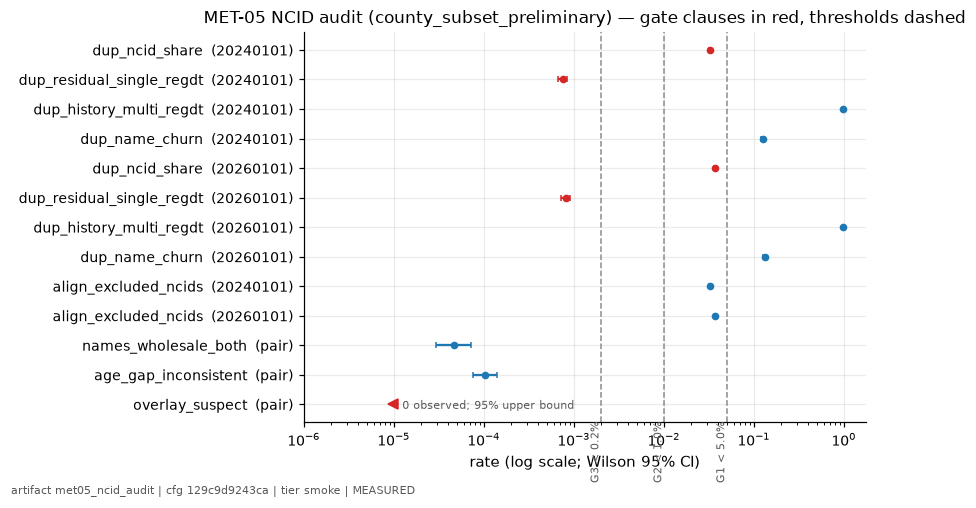

In [15]:
def draw_audit(ax, df, meta):
    df = df.reset_index(drop=True)
    labels = df["measure"] + "  (" + df["snapshot"] + ")"
    for i, row in df.iterrows():
        if row["k"] > 0:
            ax.errorbar(row["rate"], i,
                        xerr=[[row["rate"] - row["ci_low"]], [row["ci_high"] - row["rate"]]],
                        fmt="o", color="C3" if row["gate"] else "C0", capsize=2, markersize=4)
        else:  # zero count: only the one-sided Wilson upper bound is drawable on a log axis
            ax.plot(row["ci_high"], i, marker="<", color="C3", markersize=6)
            ax.annotate("0 observed; 95% upper bound", (row["ci_high"], i),
                        textcoords="offset points", xytext=(6, -3), fontsize=7, color="0.35")
    # thresholds come from the artifact itself — the figure draws nothing the table does not hold
    for _, g in df.loc[df["gate"] != "", ["gate", "threshold"]].drop_duplicates().iterrows():
        ax.axvline(g["threshold"], color="0.55", linestyle="--", linewidth=1)
        ax.annotate(f"{g['gate']} < {g['threshold']:.1%}", (g["threshold"], len(df) - 0.4),
                    rotation=90, fontsize=7, color="0.35", ha="right", va="top")
    ax.set_yticks(range(len(df)), labels)
    ax.set_xscale("log")
    ax.set_xlim(left=1e-6)
    ax.invert_yaxis()
    ax.set_xlabel("rate (log scale; Wilson 95% CI)")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="met05_ncid_audit",
    draw=draw_audit,
    title=f"MET-05 NCID audit ({GATE_SCOPE}) — gate clauses in red, thresholds dashed",
    figsize=(8.0, 4.6),
)

In [16]:
evidence = "; ".join(
    f"{r['measure']} {r['snapshot']}: {r['k']}/{r['n']} = {r['rate']:.4%} "
    f"[{r['ci_low']:.4%}, {r['ci_high']:.4%}] vs {r['gate']} < {r['threshold']:.1%} "
    f"({'pass' if r['passed'] else 'FAIL'})"
    for _, r in gated.iterrows()
)
_ = verdict_box(
    "MET-05-NCID-GATE",
    outcome="CONFIRMED" if gate_pass else "REFUTED",
    evidence=(
        f"{evidence}. History decomposition: "
        f"{profiles[SNAP_A]['multi_regdt']}/{profiles[SNAP_A]['dup_ncids']} ({SNAP_A}) and "
        f"{profiles[SNAP_B]['multi_regdt']}/{profiles[SNAP_B]['dup_ncids']} ({SNAP_B}) duplicated "
        f"ncids carry multiple registration dates. Gate decision '{gate_decision}' at scope "
        f"'{GATE_SCOPE}' recorded in met05_ncid_audit meta. Align_stats cross-check passed."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `MET-05-NCID-GATE`
>
> **Conjecture** NCID is usable as pseudo-truth for NC arms once duplicated ncids are excluded: within-snapshot duplication is dominated by retained registration history (not key errors), and genuine overlays (one ncid carrying two different people) are rare enough that entity-level metrics scored against NCID are not dominated by truth error.
>
> **Prediction** G1 < 5% of distinct ncids per snapshot (notebook 01's align_stats already recorded ~3% side-level exclusions, so this clause should pass and cross-check); G2 < 1% of distinct ncids; G3 < 0.2% of aligned pairs. All three -> preliminary pass at county subset; the DEFINITIVE gate is the statewide target-tier rerun of these same cells.
>
> **Evidence** dup_ncid_share 20240101: 13226/407815 = 3.2431% [3.1892%, 3.2979%] vs G1 < 5.0% (pass); dup_residual_single_regdt 20240101: 305/407815 = 0.0748% [0.0669%, 0.0837%] vs G2 < 1.0% (pass); dup_ncid_share 20260101: 15775/429139 = 3.6760% [3.6201%, 3.7327%] vs G1 < 5.0% (pass); dup_residual_single_regdt 20260101: 347/429139 = 0.0809% [0.0728%, 0.0898%] vs G2 < 1.0% (pass); overlay_suspect pair: 0/391257 = 0.0000% [0.0000%, 0.0010%] vs G3 < 0.2% (pass). History decomposition: 12921/13226 (20240101) and 15428/15775 (20260101) duplicated ncids carry multiple registration dates. Gate decision 'preliminary_pass' at scope 'county_subset_preliminary' recorded in met05_ncid_audit meta. Align_stats cross-check passed.


### ⚠ This is NOT the gate. The statewide target-tier run is the gate.

Read the scope stamp before quoting any number above. At smoke and mid tiers these cells audit
**a county subset over one two-year window** — counties notebook 01 chose for size, not
representativeness. County boards differ in data
hygiene; overlays concentrate where registration volume and identity collisions concentrate; a
county subset can miss statewide failure modes entirely (an overlay whose two people registered
in *different* counties is invisible here by construction, because the county filter drops one
side). A county-subset pass is therefore a **preliminary** pass: necessary to keep building,
sufficient
for nothing. The PLAN's feasibility commitment (MET-05, §3: *smoke→target*) is discharged only by
the statewide rerun of these same cells at `tier=target` on the node — same code path, no forked
logic, `corpus_registry` simply points at the statewide parquets — plus the human adjudication of
section 4's queue at its target-tier sample size. Until that run registers a statewide
`met05_ncid_audit` with `gate_decision != 'fail'`, every NC-truth arm in the matrix stays gated,
and a statewide FAIL is a *documented finding*, not a failure of the lab: NC then demotes to
noise-audit substrate (PLAN §9).

In [17]:
# [RUN-IN-TARGET node] definitive statewide MET-05 gate — this cell's real run is tier=target.
if cfg.run.tier == "target":
    print(f"tier=target: the audit above ran on the statewide snapshots — this IS the definitive "
          f"MET-05 gate. Decision: {gate_decision.upper()}. Record it in PLAN.md §10's changelog "
          f"and complete the section-4 adjudication before unlocking NC-truth arms.")
else:
    print("[RUN-IN-TARGET node] this notebook's cells compute the DEFINITIVE statewide MET-05 "
          f"gate at tier=target on the node; at tier={cfg.run.tier} they ran on the county "
          f"subset, so the decision above is scoped '{GATE_SCOPE}' and gates nothing statewide.")

[RUN-IN-TARGET node] this notebook's cells compute the DEFINITIVE statewide MET-05 gate at tier=target on the node; at tier=smoke they ran on the county subset, so the decision above is scoped 'county_subset_preliminary' and gates nothing statewide.


## 3. MET-06: even a perfect key cannot resolve everything

Flip the question. MET-05 asked whether the key lies; MET-06 asks what *no* key could fix: two
records of **different** people whose declared fields are *identical* are unresolvable in
principle — no matcher, deterministic or learned, can separate what the fields do not
distinguish (accurate ER is provably impossible unless entities are few or well separated —
lit_review §4). The unresolvable fraction is a property of the **field set**, so it is measured
per field set, from names alone up to every declared role. And NC starts with a handicap the
lab must carry everywhere: **the snapshots contain no full date of birth** — only `age` in
years, ~100 distinct values where a DOB would offer tens of thousands. Every NC-based metric in
this lab is conditioned on that ceiling (the full-DOB contrast arrives with the Ohio linkage in
ADP-02).

One definitional honesty note before the card: "different people" below means **different
NCIDs** — the very key section 2 just audited. Unresolvability measured against an imperfect key
is contaminated in a specific direction: a person holding two NCIDs whose rows agree on every
field shows up here as an "unresolvable collision between two people". The measurement cannot
separate twins from split identities; only adjudication can. We measure first, then show that
contamination explicitly.

In [18]:
_ = conjecture_card(
    card_id="MET-06-IDENTIFIABILITY",
    conjecture=(
        "Identifiability is a property of the declared field set, not of any matcher: on the NC "
        "corpus a nontrivial fraction of records is unresolvable-in-principle at every field "
        "depth, and the missing full DOB is the binding constraint — age (in years) recovers only "
        "a small part of what a DOB would."
    ),
    pressure="field-set depth: name -> +age -> +city -> all declared roles (NC has no full DOB)",
    property=(
        "in-principle unresolvable fraction: records whose exact value tuple on the field set is "
        "shared with a record of a different ncid; overall and per sex/race group"
    ),
    metric="unresolvable rate per field set with Wilson 95% CI (met06_identifiability)",
    prediction=(
        "Rates decrease monotonically with field depth; name-only exceeds 5% (birthday-problem "
        "arithmetic on a few hundred thousand records with no DOB); adding age removes less than "
        "half of the name-only mass (a ~100-value field is far coarser than a DOB); the all-roles "
        "floor stays strictly above zero — an irreducible fraction every later headline metric "
        "must report and may only condition away in the open."
    ),
    registry=registry,
)

### Conjecture card `MET-06-IDENTIFIABILITY`

| | |
|---|---|
| **Conjecture** | Identifiability is a property of the declared field set, not of any matcher: on the NC corpus a nontrivial fraction of records is unresolvable-in-principle at every field depth, and the missing full DOB is the binding constraint — age (in years) recovers only a small part of what a DOB would. |
| **Pressure (dial)** | field-set depth: name -> +age -> +city -> all declared roles (NC has no full DOB) |
| **Embedding property** | in-principle unresolvable fraction: records whose exact value tuple on the field set is shared with a record of a different ncid; overall and per sex/race group |
| **System metric** | unresolvable rate per field set with Wilson 95% CI (met06_identifiability) |
| **Pre-registered prediction** | Rates decrease monotonically with field depth; name-only exceeds 5% (birthday-problem arithmetic on a few hundred thousand records with no DOB); adding age removes less than half of the name-only mass (a ~100-value field is far coarser than a DOB); the all-roles floor stays strictly above zero — an irreducible fraction every later headline metric must report and may only condition away in the open. |

*Immutable — sha256 `260b9fae26d6`; registered before the affected runs, never edited (PLAN §5).*


The four field sets, from the `nc_voter` declared roles. `snapshot_date` is excluded (constant
within a snapshot — it pads every tuple equally and distinguishes nothing); `record_id` is
re-keyed as `county_id:voter_reg_num` because NC's registration numbers are only unique per
county — the same line of code that makes the statewide target run correct. Missing values
compare equal to missing values by design: two records that both lack a phone present identical
information to any matcher restricted to these fields.

In [19]:
ALL_ROLES = ["given_name", "middle_name", "family_name", "name_suffix", "age", "sex", "race",
             "ethnicity", "house_number", "street", "unit", "city", "state", "zip", "phone",
             "county"]
FIELD_SETS = {
    "name": ["given_name", "middle_name", "family_name", "name_suffix"],
    "name+age": ["given_name", "middle_name", "family_name", "name_suffix", "age"],
    "name+age+city": ["given_name", "middle_name", "family_name", "name_suffix", "age", "city"],
    "all_roles": ALL_ROLES,
}
IDENT_SNAP = SNAP_B  # the newer snapshot — the corpus later notebooks actually dedup
ident_frame = pd.read_parquet(snap_paths[IDENT_SNAP])
ident_frame["record_id"] = (
    ident_frame["county_id"].str.strip() + ":" + ident_frame["record_id"].astype(str)
)
assert not ident_frame["record_id"].duplicated().any(), "county:regnum must be unique"
print(f"identifiability corpus: snapshot {IDENT_SNAP}, {len(ident_frame)} records, "
      f"{ident_frame['entity_id'].nunique()} distinct ncids")

identifiability corpus: snapshot 20260101, 447450 records, 429139 distinct ncids


In [20]:
met06_rows = []
for label, fields in FIELD_SETS.items():
    t0 = time.time()
    rep = unresolvable_report(ident_frame, fields)
    r = rep.iloc[0]
    met06_rows.append({"field_set": label, "grouping": "overall", "group": "all",
                       "n": int(r["n"]), "n_unresolvable": int(r["n_unresolvable"])})
    print(f"{label:>14}: {int(r['n_unresolvable']):>6} / {int(r['n'])} unresolvable "
          f"({r['rate']:.3%})  [{time.time() - t0:.1f}s]")
for by in ("sex", "race"):
    rep = unresolvable_report(ident_frame, FIELD_SETS["all_roles"], by=[by]).iloc[1:]
    for _, r in rep.iterrows():
        blank = pd.isna(r[by]) or not str(r[by]).strip()
        met06_rows.append({"field_set": "all_roles", "grouping": by,
                           "group": "(blank)" if blank else str(r[by]).strip(),
                           "n": int(r["n"]), "n_unresolvable": int(r["n_unresolvable"])})
met06 = pd.DataFrame(met06_rows)
cis = [wilson_ci(k, n) for k, n in zip(met06["n_unresolvable"], met06["n"])]
met06["rate"] = met06["n_unresolvable"] / met06["n"]
met06["ci_low"] = [lo for lo, _ in cis]
met06["ci_high"] = [hi for _, hi in cis]

          name:  38039 / 447450 unresolvable (8.501%)  [0.5s]


      name+age:  34152 / 447450 unresolvable (7.633%)  [0.5s]


 name+age+city:  23917 / 447450 unresolvable (5.345%)  [0.6s]


     all_roles:   4621 / 447450 unresolvable (1.033%)  [1.4s]


In [21]:
registry.register(
    "met06_identifiability",
    met06,
    cfg=cfg,
    tier=cfg.run.tier,
    meta={
        "snapshot": IDENT_SNAP,
        "n_records": len(ident_frame),
        "field_sets": {k: list(v) for k, v in FIELD_SETS.items()},
        "entity_key": "ncid (audited by MET-05 — unresolvability is measured AGAINST this key)",
        "scope": GATE_SCOPE,
        "missing_semantics": "missing == missing (identical information to any matcher)",
    },
)
display(met06[met06["grouping"] == "overall"])
print("\nper-group breakdown at the richest field set (all_roles):")
display(met06[met06["grouping"] != "overall"].sort_values(["grouping", "n"], ascending=[True, False]))

,field_set,grouping,group,n,n_unresolvable,rate,ci_low,ci_high
0,name,overall,all,447450,38039,0.085013,0.084199,0.085834
1,name+age,overall,all,447450,34152,0.076326,0.075551,0.077107
2,name+age+city,overall,all,447450,23917,0.053452,0.052797,0.054115
3,all_roles,overall,all,447450,4621,0.010327,0.010035,0.010628



per-group breakdown at the richest field set (all_roles):


,field_set,grouping,group,n,n_unresolvable,rate,ci_low,ci_high
14,all_roles,race,W,336011,3718,0.011065,0.010717,0.011424
8,all_roles,race,B,51151,655,0.012805,0.011867,0.013817
13,all_roles,race,U,28181,151,0.005358,0.004571,0.006281
11,all_roles,race,O,13655,34,0.002490,0.001782,0.003477
7,all_roles,race,A,13197,47,0.003561,0.002679,0.004732
10,all_roles,race,M,4208,14,0.003327,0.001983,0.005577
9,all_roles,race,I,1037,2,0.001929,0.000529,0.007005
12,all_roles,race,P,10,0,0.000000,0.000000,0.277533
4,all_roles,sex,F,232689,2260,0.009713,0.009322,0.010119
5,all_roles,sex,M,189977,2247,0.011828,0.011351,0.012324


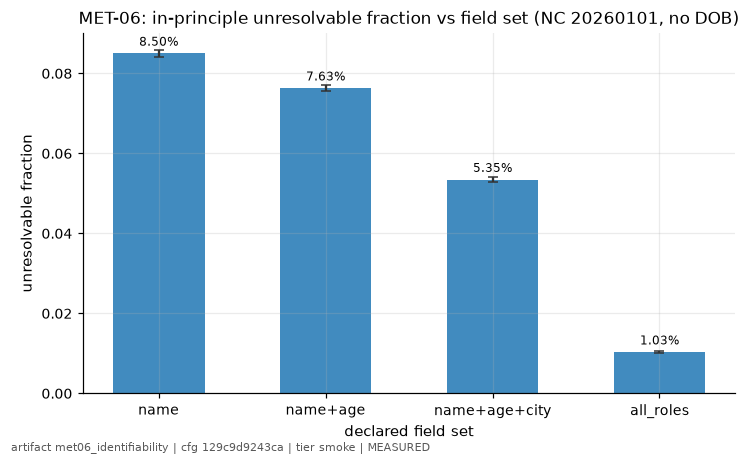

In [22]:
def draw_ident(ax, df, meta):
    overall = df[df["grouping"] == "overall"].reset_index(drop=True)
    x = np.arange(len(overall))
    ax.bar(x, overall["rate"], width=0.55, color="C0", alpha=0.85)
    ax.errorbar(x, overall["rate"],
                yerr=[overall["rate"] - overall["ci_low"], overall["ci_high"] - overall["rate"]],
                fmt="none", ecolor="0.2", capsize=3)
    for i, row in overall.iterrows():
        ax.annotate(f"{row['rate']:.2%}", (i, row["rate"]),
                    textcoords="offset points", xytext=(0, 5), ha="center", fontsize=8)
    ax.set_xticks(x, overall["field_set"])
    ax.set_xlabel("declared field set")
    ax.set_ylabel("unresolvable fraction")


fig = figures.plot_artifact(
    registry,
    tier=cfg.run.tier,
    artifact="met06_identifiability",
    draw=draw_ident,
    title=f"MET-06: in-principle unresolvable fraction vs field set (NC {IDENT_SNAP}, no DOB)",
    figsize=(6.8, 4.2),
)

### The floor is not all twins — MET-05 leaks into MET-06

Look at the all-roles collisions before believing the floor. A record unresolvable at *all
sixteen roles* means another NCID carries an identical name, suffix, age, sex, race, ethnicity,
house number, street, unit, city, zip, *and phone*. Genuinely different people do that rarely
(even twins differ in given name). The parsimonious reading for much of this set is the other
NCID error class — **split identities**: one person, two keys, typically an old removed row under
one NCID and a re-registration under another. The cells below measure two signatures on the
collision groups (how many pair exactly two NCIDs; how many share a single registration date —
the same-day re-key smoking gun) and display masked examples. The point is not to resolve them
here — the file alone cannot — but to show *measured* evidence that MET-06's floor is
contaminated by MET-05's key errors, which is exactly why the floor must be adjudicated, not
assumed, before SCL-04 treats it as irreducible ambiguity.

In [23]:
mask_all = unresolvable_mask(ident_frame, fields=ALL_ROLES)
collided = ident_frame[mask_all.to_numpy()]
sig = collided.groupby(ALL_ROLES, dropna=False).agg(
    n_ncid=("entity_id", "nunique"), n_regdt=("registr_dt", "nunique"), rows=("entity_id", "size")
)
n_groups = len(sig)
two_ncids = int((sig["n_ncid"] == 2).sum())
same_day = int((sig["n_regdt"] == 1).sum())
for name, k in (("collision_pairs_two_ncids", two_ncids), ("collision_same_regdt", same_day)):
    lo, hi = wilson_ci(k, n_groups)
    print(f"{name:>26}: {k:>5} / {n_groups} collision groups = {k / n_groups:.2%} "
          f"CI [{lo:.2%}, {hi:.2%}]")
print("\nmasked examples (initials only; each row pair = one collision group):")
ex = collided.sort_values(ALL_ROLES).head(6)
display(pd.DataFrame({
    "ncid": ex["entity_id"].str.slice(0, 4) + "…",
    "name": (ex["given_name"].str.strip().str.slice(0, 1) + ". "
             + ex["family_name"].str.strip().str.slice(0, 1) + "."),
    "age": ex["age"].str.strip(),
    "city": ex["city"].str.strip(),
    "status": ex["status_cd"].str.strip(),
    "registr_dt": ex["registr_dt"].str.strip(),
}).reset_index(drop=True))

 collision_pairs_two_ncids:  2232 / 2268 collision groups = 98.41% CI [97.81%, 98.85%]
      collision_same_regdt:   170 / 2268 collision groups = 7.50% CI [6.48%, 8.65%]

masked examples (initials only; each row pair = one collision group):


,ncid,name,age,city,status,registr_dt
0,DE22…,A. S.,50,HILLSBOROUGH,R,05/02/2005
1,DE36…,A. S.,50,HILLSBOROUGH,R,10/25/2024
2,DE15…,A. S.,50,HILLSBOROUGH,R,01/29/1997
3,DE21…,A. V.,43,CHAPEL HILL,R,09/28/2004
4,DE21…,A. V.,43,CHAPEL HILL,D,06/24/2004
5,DE32…,A. N.,23,ROUGEMONT,A,12/09/2019


In [24]:
overall_rates = met06[met06["grouping"] == "overall"].set_index("field_set")["rate"]
mono = bool(overall_rates.is_monotonic_decreasing)
checks = {
    "monotone decrease with field depth": mono,
    "name-only > 5%": bool(overall_rates["name"] > 0.05),
    "age removes < half of name-only mass": bool(
        overall_rates["name+age"] > 0.5 * overall_rates["name"]
    ),
    "all-roles floor > 0": bool(overall_rates["all_roles"] > 0),
}
outcome = "CONFIRMED" if all(checks.values()) else "REFUTED"
_ = verdict_box(
    "MET-06-IDENTIFIABILITY",
    outcome=outcome,
    evidence=(
        f"Unresolvable rates: {', '.join(f'{k}={v:.3%}' for k, v in overall_rates.items())} "
        f"(met06_identifiability, n={len(ident_frame)}, Wilson CIs in the artifact). Checks: "
        f"{checks}. Caveat carried into the artifact meta: the all-roles floor is measured "
        f"against ncid and is contaminated by split identities — {two_ncids}/{n_groups} collision "
        f"groups pair exactly two ncids and {same_day}/{n_groups} share a single registration "
        f"date; the floor is an upper bound on true twin/collision ambiguity pending section-4 "
        f"adjudication."
    ),
    registry=registry,
)

> ### VERDICT: CONFIRMED — card `MET-06-IDENTIFIABILITY`
>
> **Conjecture** Identifiability is a property of the declared field set, not of any matcher: on the NC corpus a nontrivial fraction of records is unresolvable-in-principle at every field depth, and the missing full DOB is the binding constraint — age (in years) recovers only a small part of what a DOB would.
>
> **Prediction** Rates decrease monotonically with field depth; name-only exceeds 5% (birthday-problem arithmetic on a few hundred thousand records with no DOB); adding age removes less than half of the name-only mass (a ~100-value field is far coarser than a DOB); the all-roles floor stays strictly above zero — an irreducible fraction every later headline metric must report and may only condition away in the open.
>
> **Evidence** Unresolvable rates: name=8.501%, name+age=7.633%, name+age+city=5.345%, all_roles=1.033% (met06_identifiability, n=447450, Wilson CIs in the artifact). Checks: {'monotone decrease with field depth': True, 'name-only > 5%': True, 'age removes < half of name-only mass': True, 'all-roles floor > 0': True}. Caveat carried into the artifact meta: the all-roles floor is measured against ncid and is contaminated by split identities — 2232/2268 collision groups pair exactly two ncids and 170/2268 share a single registration date; the floor is an upper bound on true twin/collision ambiguity pending section-4 adjudication.


### What conditioning means for every later metric

From here on, every headline figure in the lab reports its unresolvable fraction, and any metric
*conditioned* on the resolvable subset must appear **alongside** the unconditioned number, never
instead of it (`eval.identifiability.conditioned` enforces the bookkeeping; PLAN §5 the policy).
The reason is adversarial: conditioning silently is free accuracy — drop the hopeless records
and every method looks better, embeddings and rules alike, without either having improved. The
NC-specific sting is that the no-DOB ceiling is *shared* across all compared systems, so it
cannot reverse a ranking by itself — but the per-group table above shows the unresolvable mass is
**not uniform across sex and race groups**, so conditioning changes *whose* records are scored,
and FAIR-01's disparity measurements must use the unconditioned metrics with the per-group
unresolvable fractions reported next to them. That per-group asymmetry is also the first
concrete instance of a pattern this lab will keep meeting: data limitations are never neutral.

## 4. The adjudication protocol: when the file cannot answer, a human must

Sections 2 and 3 ended at the same wall from opposite sides: pairs the *file* cannot classify
(overlay vs legal name change; twin vs split identity). The lab's answer is pre-committed human
adjudication through `label.widget` — deliberately boring machinery with three honesty
properties: the queue order is **deterministic** (canonical pair orientation, sorted, de-duped —
two annotators see the same sequence and a re-run resumes identically); decisions persist as
**append-only JSONL** (changes of mind stay visible, nothing is ever edited in place); and
`unsure` is a **first-class label**, because MET-06 just established that some pairs are
genuinely unresolvable and the protocol must be able to say so rather than forcing a coin flip.

Below, the queue is *constructed* on real disagreement-stratum pairs from this run — strict
suspects first, then the two near-suspect margins, then a random control draw — and its first
item is displayed (masked). At smoke no one labels: the cell demonstrates the exact object the
target-tier adjudicator will drive (`AdjudicationWidget(queue)` in a live notebook on the node).

In [25]:
rng = np.random.default_rng(cfg.run.seed)
n_ctrl = max(2, QUEUE_N // 5)
ranked_ncids = list(
    pd.concat([
        flags.loc[flags["overlay_suspect"], "ncid"],
        wholesale_only["ncid"],
        age_only["ncid"],  # already sorted worst-gap-first above
    ]).drop_duplicates()
)[: QUEUE_N - n_ctrl]
control_pool = aligned.loc[~aligned["ncid"].isin(ranked_ncids), "ncid"]
control = list(control_pool.iloc[rng.choice(len(control_pool), size=n_ctrl, replace=False)])
stratum = (["disagreement"] * len(ranked_ncids)) + (["random_control"] * len(control))
chosen = ranked_ncids + control

q_fields = ["given_name", "middle_name", "family_name", "age", "sex",
            "street", "city", "status_cd", "registr_dt"]
sel = aligned.set_index("ncid").loc[chosen]
records_df = pd.concat([
    sel[[f + "_" + s for f in q_fields]].rename(columns=lambda c: c[:-2])
    .assign(snapshot=d, record_id=[f"{n}:{d}" for n in chosen])
    for s, d in (("a", SNAP_A), ("b", SNAP_B))
])
pairs_df = pd.DataFrame({
    "a": [f"{n}:{SNAP_A}" for n in chosen],
    "b": [f"{n}:{SNAP_B}" for n in chosen],
    "stratum": stratum,
})
queue = PairQueue(pairs_df, records_df,
                  path=REPO_ROOT / "data" / "labels" / f"met05_adjudication_{cfg.run.tier}.jsonl")
def mask_pair_id(pid: str) -> str:
    """'NCID:date||NCID:date' with both ncids truncated, for display only."""
    left, right = pid.split("||")
    return " || ".join(s.split(":")[0][:4] + "…:" + s.split(":")[1] for s in (left, right))


print(f"PairQueue constructed: {len(queue)} pairs "
      f"({len(ranked_ncids)} disagreement-stratum + {len(control)} random control), "
      f"deterministic order, JSONL path set.")
print("first 3 pair ids (ncids masked for display): "
      f"{[mask_pair_id(p) for p in queue.pair_ids()[:3]]}")

PairQueue constructed: 10 pairs (8 disagreement-stratum + 2 random control), deterministic order, JSONL path set.
first 3 pair ids (ncids masked for display): ['BL28…:20240101 || BL28…:20260101', 'BL40…:20240101 || BL40…:20260101', 'DE19…:20240101 || DE19…:20260101']


In [26]:
# The first queue item, masked for display (the queue itself holds verbatim values).
item = next(iter(queue))


def masked_record(rec: dict) -> dict:
    out = dict(rec)
    for f in ("given_name", "middle_name", "family_name"):
        v = str(out.get(f) or "").strip()
        out[f] = (v[:1] + ".") if v else "-"
    return out


print(f"pair_id : {item['pair_id'][:4]}…:{SNAP_A} || {item['pair_id'][:4]}…:{SNAP_B} "
      f"(stratum: {item['stratum']})")
display(pd.DataFrame({"record_a": masked_record(item["record_a"]),
                      "record_b": masked_record(item["record_b"])}))

pair_id : BL28…:20240101 || BL28…:20260101 (stratum: disagreement)


,record_a,record_b
given_name,K.,D.
middle_name,R.,K.
family_name,B.,R.
age,49,51
sex,F,F
street,FAIROAKS CIR,FAIROAKS CIR
city,CHAPEL HILL,CHAPEL HILL
status_cd,I,A
registr_dt,2006-03-17,03/17/2006
snapshot,20240101,20260101


### The target-tier sampling plan, sized now

The statewide adjudication answers one estimation question — *what fraction of flagged
disagreements are real key errors?* — so its sample size comes from the CI width we can act on,
computed here (normal-approximation planning; the analysis itself will report Wilson intervals):
at worst-case variance (p = 0.5) and a ±5-point half-width, the required n lands inside the
PLAN §10 commitment of ~200–500 labeled pairs. Allocation is **disagreement-stratified**: every
strict overlay suspect (they should be rare statewide, and each one is a direct truth-error
specimen), capped equal shares of the two near-suspect margins and the split-identity collision
stratum from MET-06, plus a random-control stratum to catch the errors our definitions missed.
**Inter-rater plan:** two annotators label an overlapping block of the queue (the first 100
pairs in queue order — determinism makes "first 100" identical for both); agreement is quoted as
Cohen's kappa (`label.widget.cohens_kappa`) with `unsure` kept as its own category; the
pre-committed acceptance line is kappa >= 0.7, below which the label taxonomy (not the
annotators) is declared inadequate, revised, and the block relabeled — disagreement patterns are
themselves MET-05 evidence.

In [27]:
P_DESIGN, HALF_WIDTH = 0.5, 0.05
n_adjudicate = math.ceil(Z95**2 * P_DESIGN * (1 - P_DESIGN) / HALF_WIDTH**2)
assert 200 <= n_adjudicate <= 500, "outside the PLAN §10 commitment band — revisit the design"
n_overlap = 100
# equal caps over the three non-suspect disagreement strata, 20% control:
n_control_t = round(0.2 * n_adjudicate)
per_stratum = (n_adjudicate - n_control_t) // 3
plan = {
    "n_total": int(n_adjudicate),
    "design": f"CI half-width {HALF_WIDTH} at p={P_DESIGN} (z={Z95:.3f}); Wilson at analysis",
    "strata": {
        "overlay_suspect": "ALL statewide strict suspects (uncapped; each is a specimen)",
        "names_wholesale_both": f"up to {per_stratum} (worst first, deterministic order)",
        "age_gap_inconsistent": f"up to {per_stratum} (worst gap first)",
        "allroles_collision_split_identity": f"up to {per_stratum} (MET-06 stratum)",
        "random_control": f"{n_control_t} pairs, seeded draw (seed={int(cfg.run.seed)})",
    },
    "inter_rater": {
        "overlap_block": f"first {n_overlap} pairs in queue order, both annotators",
        "statistic": "Cohen's kappa via label.widget.cohens_kappa, 'unsure' kept as a category",
        "acceptance": "kappa >= 0.7, else revise the label taxonomy and relabel the block",
    },
}
registry.register("met05_adjudication_plan", plan, cfg=cfg, tier=cfg.run.tier,
                  meta={"scope": GATE_SCOPE, "queue_demo_size": len(queue)})
print(f"target-tier adjudication n = {n_adjudicate} "
      f"(within PLAN §10's 200-500 band: {200 <= n_adjudicate <= 500})")
for k, v in plan["strata"].items():
    print(f"  {k:>34}: {v}")
print(f"  inter-rater overlap block: {n_overlap} pairs, acceptance kappa >= 0.7")

target-tier adjudication n = 385 (within PLAN §10's 200-500 band: True)
                     overlay_suspect: ALL statewide strict suspects (uncapped; each is a specimen)
                names_wholesale_both: up to 102 (worst first, deterministic order)
                age_gap_inconsistent: up to 102 (worst gap first)
   allroles_collision_split_identity: up to 102 (MET-06 stratum)
                      random_control: 77 pairs, seeded draw (seed=17)
  inter-rater overlap block: 100 pairs, acceptance kappa >= 0.7


## What we now know

- **The truth key's failure modes are now measured, not assumed — at county-subset scope.**
  Within-snapshot NCID duplication exists at the percent level but is overwhelmingly retained
  registration *history* (multiple registration dates under one key), not key error; the residual
  that history cannot explain is an order of magnitude smaller. Strict cross-snapshot overlay
  suspects — both names wholesale-different *and* an impossible age gap — are rare to absent
  here, with the zero-count case honestly bounded by its one-sided Wilson interval. All measures,
  CIs, gate thresholds, and the scoped gate decision live in `met05_ncid_audit`; the verdict box
  scored the pre-registered card clause by clause.
- **The gate decision is explicitly provisional.** A county subset cannot see cross-county
  overlays by construction. The definitive MET-05 gate is the statewide `tier=target` rerun of
  these same cells plus the adjudicated sample — until then, NC-truth arms stay gated.
- **The substrate exclusion is a selection effect we carry forward.** `align_pair`'s
  duplicate-NCID exclusions (cross-checked here against notebook 01's recorded stats, hard-assert)
  preferentially drop re-registrants — mobile people — so notebook 04's measured noise prevalence
  is a stable-registrant lower bound for that subpopulation.
- **Identifiability has a measured floor, and the floor is not innocent.** The unresolvable
  fraction falls monotonically from names-only to all sixteen declared roles but never reaches
  zero — and NC's missing DOB means `age` recovers only a modest part of the name-collision mass.
  The all-roles floor itself carries MET-05's fingerprints: collision groups overwhelmingly pair
  exactly two NCIDs, a split-identity signature, so the floor is an *upper bound* on true
  ambiguity pending adjudication. Rates, per-sex and per-race breakdowns, and CIs are in
  `met06_identifiability`.
- **The adjudication protocol exists and is sized.** A deterministic `PairQueue` over real
  disagreement strata was constructed (labels are append-only JSONL; `unsure` is first-class),
  and the target-tier plan — stratified allocation around a computed n within the PLAN §10 band,
  a fixed overlap block, kappa >= 0.7 acceptance — is registered as `met05_adjudication_plan`.

## What this changes downstream

- **Notebook 04 (NSE-01)** audits the aligned diffs knowing the substrate's selection bias and
  inherits the diff-mix preview convention (Wilson CIs from `noise.audit.prevalence`).
- **Every NC-truth arm** (BAS-01 on NC, temporal eval pairs, the notebook-11 circular-teacher
  study) remains conditional on the statewide MET-05 gate; the artifact meta's
  `gate_decision`/`scope` is the machine-readable switch.
- **Every headline metric from notebook 06 onward** reports the unresolvable fraction from
  `met06_identifiability` and may condition on resolvability only alongside the unconditioned
  number; FAIR-01 must use the per-group breakdown, since the unresolvable mass is not uniform
  across sex or race.
- **SCL-04's ambiguity budget** starts from the all-roles floor measured here — minus whatever
  the adjudication reveals to be split identities rather than true collisions.

**Artifacts registered** (exact names): `met05_ncid_audit`, `met06_identifiability` — plus the
supporting `met05_adjudication_plan` and the immutable cards `card_MET-05-NCID-GATE` and
`card_MET-06-IDENTIFIABILITY`.

In [28]:
print(f"notebook wall-clock: {time.time() - NB_T0:.0f}s")

notebook wall-clock: 18s
